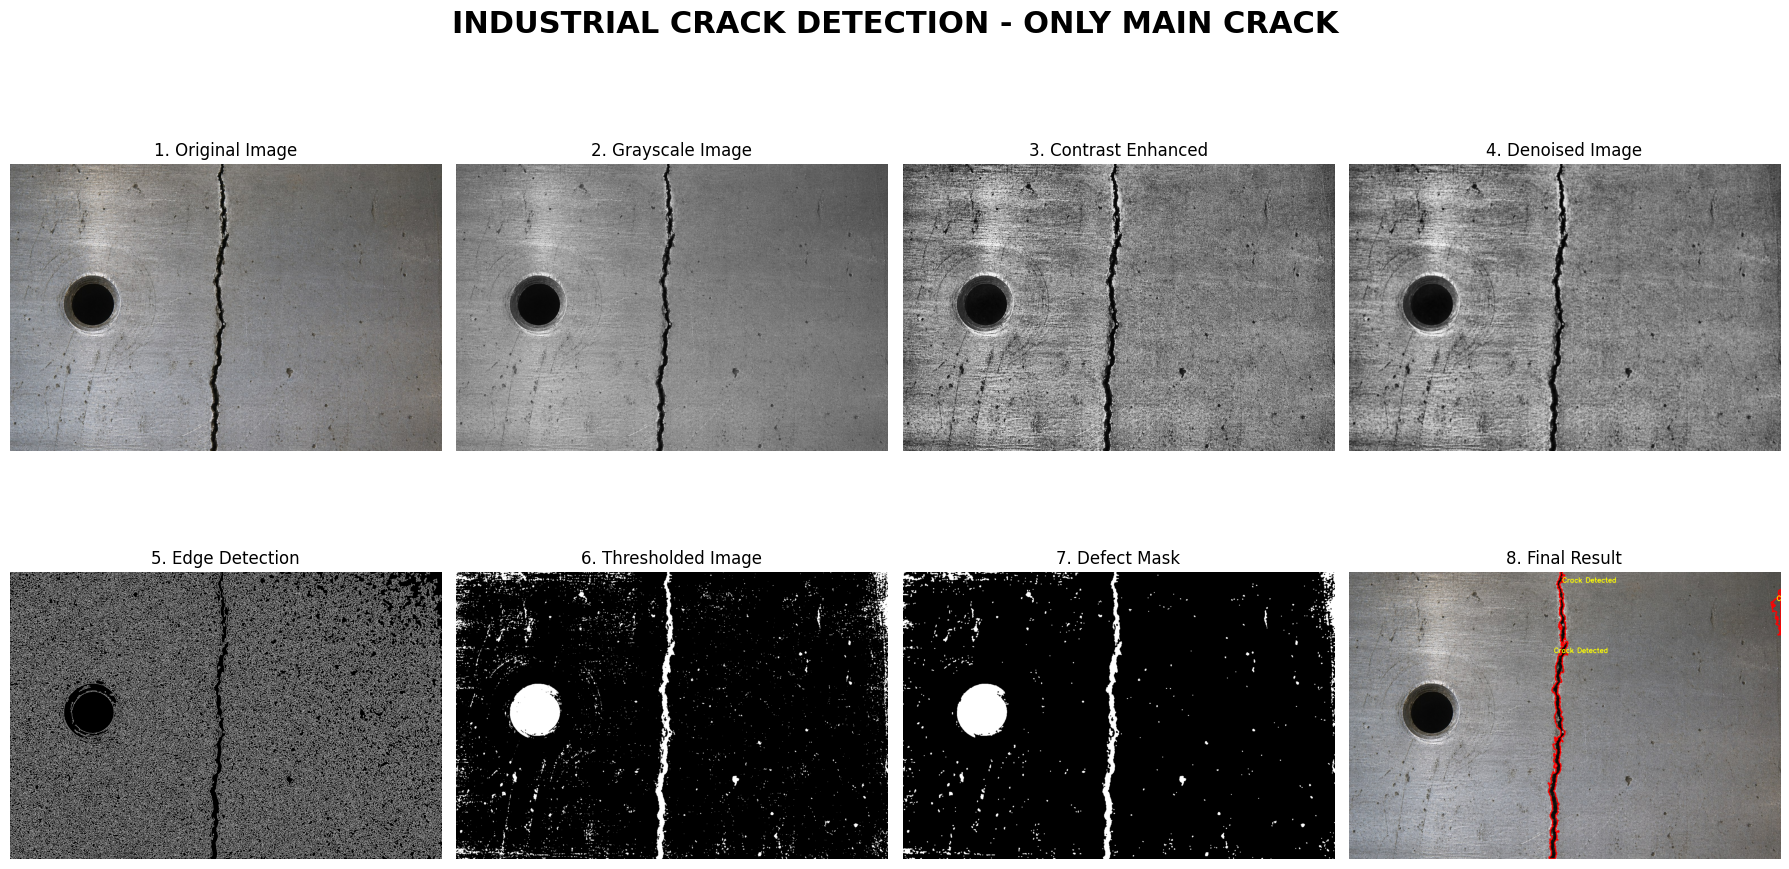

In [ ]:
# ==========================================
# INDUSTRIAL CRACK DETECTION (ONLY MAIN CRACK)
# Google Colab Version
# Removes circular hole and detects only crack
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. READ IMAGE
# -------------------------------
img = cv2.imread('/content/sample_data/dip_image.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------------------------------
# 2. GRAYSCALE IMAGE
# -------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# -------------------------------
# 3. CONTRAST ENHANCEMENT
# -------------------------------
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
contrast = clahe.apply(gray)

# -------------------------------
# 4. DENOISED IMAGE
# -------------------------------
denoise = cv2.GaussianBlur(contrast, (5,5), 0)

# -------------------------------
# 5. EDGE DETECTION
# -------------------------------
edges = cv2.Canny(denoise, 50, 150)

# -------------------------------
# 6. THRESHOLD IMAGE
# -------------------------------
_, thresh = cv2.threshold(denoise, 80, 255, cv2.THRESH_BINARY_INV)

# -------------------------------
# 7. DEFECT MASK
# -------------------------------
kernel = np.ones((3,3), np.uint8)
mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# -------------------------------
# 8. FINAL RESULT (ONLY CRACK)
# -------------------------------
result = img.copy()

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:

    area = cv2.contourArea(cnt)
    x,y,w,h = cv2.boundingRect(cnt)

    # Only long vertical crack
    if area > 500 and h > w * 3:

        cv2.drawContours(result, [cnt], -1, (255,0,0), 3)

        cv2.putText(result, "Crack Detected",
                    (x+20, y+40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (255,255,0), 2)

# ======================================
# DISPLAY ALL RESULTS
# ======================================

fig = plt.figure(figsize=(18,10))
fig.suptitle("INDUSTRIAL CRACK DETECTION - ONLY MAIN CRACK",
             fontsize=22, fontweight='bold')

titles = [
    "1. Original Image",
    "2. Grayscale Image",
    "3. Contrast Enhanced",
    "4. Denoised Image",
    "5. Edge Detection",
    "6. Thresholded Image",
    "7. Defect Mask",
    "8. Final Result"
]

images = [
    img,
    gray,
    contrast,
    denoise,
    edges,
    thresh,
    mask,
    result
]

for i in range(8):
    plt.subplot(2,4,i+1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i], fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()